In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygments.lexers import factor

In [259]:
data = pd.read_parquet('../data/processed/data.parquet')

In [260]:
data = data.sort_values(by=['eom', 'id'], ascending = True)

In [261]:
data['ret'].min()

np.float64(-0.999993846)

In [262]:
for col in data.columns.to_list():
    print(col)

id
date
eom
source_crsp
size_grp
obs_main
exch_main
primary_sec
gvkey
iid
permno
permco
excntry
curcd
fx
common
comp_tpci
crsp_shrcd
comp_exchg
crsp_exchcd
adjfct
shares
me_lag1
gics
sic
naics
ff49
me_company
prc
prc_local
dolvol
ret
ret_lag_dif
ret_exc_lead1m
enterprise_value
book_equity
assets
sales
net_income
bidask
prc_high
prc_low
tvol
div1m_me
div3m_me
div6m_me
div12m_me
divspc1m_me
divspc12m_me
chcsho_1m
chcsho_3m
chcsho_6m
chcsho_12m
eqnpo_1m
eqnpo_3m
eqnpo_6m
eqnpo_12m
ret_1_0
ret_2_0
ret_3_0
ret_3_1
ret_6_0
ret_6_1
ret_9_0
ret_9_1
ret_12_0
ret_12_1
ret_12_7
ret_18_1
ret_24_1
ret_24_12
ret_36_1
ret_36_12
ret_48_12
ret_48_1
ret_60_1
ret_60_12
ret_60_36
seas_1_1an
seas_1_1na
seas_2_5an
seas_2_5na
seas_6_10an
seas_6_10na
seas_11_15an
seas_11_15na
seas_16_20an
seas_16_20na
at_gr1
ca_gr1
nca_gr1
lt_gr1
cl_gr1
ncl_gr1
be_gr1
pstk_gr1
debt_gr1
sale_gr1
cogs_gr1
sga_gr1
opex_gr1
capx_gr1
inv_gr1
at_gr3
ca_gr3
nca_gr3
lt_gr3
cl_gr3
ncl_gr3
be_gr3
pstk_gr3
debt_gr3
sale_gr3
cogs_gr3
sga

In [263]:
len(data.columns)

438

In [264]:
port = pd.read_csv('../data/backtest/xgboost_expanding/portfolios.csv')
port

,id,leg,weight,predicted_ret,realized_ret,eom
0,100172801,long,0.004739,0.011092,0.195962,1986-01-31
1,101158401,long,0.004739,0.011092,0.090322,1986-01-31
2,100684801,long,0.004739,0.011422,0.029792,1986-01-31
3,100518401,long,0.004739,0.011476,0.217968,1986-01-31
4,101034501,long,0.004739,0.011092,0.013109,1986-01-31
...,...,...,...,...,...,...
279775,115473901,short,-0.004464,0.006587,-0.026598,2025-10-31
279776,102067701,short,-0.004464,0.005667,-0.025059,2025-10-31
279777,101312501,short,-0.004464,0.006587,0.020233,2025-10-31
279778,127134201,short,-0.004464,0.005622,0.124835,2025-10-31


In [265]:
# # port[(port['eom'] == '2018-06-30' and port['leg'] == 'short')]
# temp = port[(port['eom'] == '2018-06-30') & (port['leg'] == 'long')]

In [266]:
# temp['realized_ret'].min()

In [267]:
# ticker_116646001 = df[df['id'] == 116646001]
# ticker_116646001 = ticker_116646001[['eom', 'ret']]

In [268]:
# # Make sure eom is datetime
# ticker_116646001['eom'] = pd.to_datetime(ticker_116646001['eom'])
#
# # Sort by date
# df = ticker_116646001.sort_values('eom').copy()
#
# # Cumulative return
# df['cum_ret'] = df['ret'].cumsum()
#
# # Split into 3 equal chunks
# n = len(df)
# chunk_size = n // 3
#
# chunks = [
#     df.iloc[:chunk_size],
#     df.iloc[chunk_size:2 * chunk_size],
#     df.iloc[2 * chunk_size:]
# ]
#
# for i, chunk in enumerate(chunks, 1):
#     plt.figure(figsize=(12, 5))
#     plt.plot(chunk['eom'], chunk['cum_ret'])
#     plt.xlabel('EOM')
#     plt.ylabel('Cumulative Return')
#     plt.title(f'Cumulative Returns (Period {i})')
#     plt.xticks(rotation=45)
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

In [269]:
# cum_ret = ticker_116646001['ret'].cumsum()
#
# max_idx = cum_ret.idxmax()
# max_return = cum_ret.loc[max_idx]
# max_date = ticker_116646001.loc[max_idx, 'eom']
#
# print(max_return)
# print(max_date)

In [270]:
# cum_ret

In [271]:
# there is a stock that I shorted on that day which generated a return of over 400 (not 400%). This is what caused the sharp spike in the cumulative return.

In [272]:
# ret_2018 = ticker_116646001.loc[
#     ticker_116646001['eom'].dt.year == 2018,
#     'ret'
# ]
# ret_2018

In [273]:
rets_df = pd.read_csv('../data/backtest/xgboost_expanding/monthly_returns.csv')
# rets_df[['long_ret', 'short_ret']].cumsum().plot()
# rets = rets_df['long_ret'] - rets_df['short_ret']
# np.where(rets == rets.min())[0]

In [274]:
rets_df

,eom,ic_pearson,ic_spearman,best_iteration,n_train,scoring_year,train_end_year,long_ret,short_ret,qspread,net_qspread,turnover,n_long,n_short,n_universe
0,1986-01-31,0.090937,0.102197,1,149849,1986,1985,0.083575,0.045873,0.037702,0.035702,1.000000,211,211,2115
1,1986-02-28,0.038540,0.010804,1,149849,1986,1985,0.035217,0.031445,0.003772,0.002989,0.391509,212,212,2123
2,1986-03-31,-0.015516,-0.015706,1,149849,1986,1985,0.005058,0.003928,0.001129,0.000088,0.520642,218,218,2182
3,1986-04-30,0.047174,0.031694,1,149849,1986,1985,0.038992,0.022023,0.016969,0.016184,0.392694,219,219,2195
4,1986-05-31,0.072610,0.077839,1,149849,1986,1985,0.013235,-0.018684,0.031919,0.031192,0.363636,220,220,2205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,2025-06-30,-0.001869,0.042726,15,1753119,2025,2024,0.017110,-0.000192,0.017302,0.016858,0.221973,223,223,2231
474,2025-07-31,0.060465,0.080294,15,1753119,2025,2024,0.077468,0.049608,0.027861,0.027203,0.328829,222,222,2224
475,2025-08-31,0.107696,0.053533,15,1753119,2025,2024,0.008417,-0.017102,0.025519,0.024908,0.305804,224,224,2245
476,2025-09-30,-0.068273,-0.017841,15,1753119,2025,2024,-0.042502,-0.034353,-0.008149,-0.008602,0.226667,225,225,2259


In [275]:
rets_df['qspread'].max()

np.float64(0.2265084422177966)

In [276]:
rets_df.loc[rets_df['qspread'] >= 0.2, 'eom']

278    2009-03-31
Name: eom, dtype: str

In [277]:
rets_df.loc[rets_df['long_ret'] >= 0.3, 'eom']

278    2009-03-31
417    2020-10-31
Name: eom, dtype: str

In [278]:
port = pd.read_csv('../data/backtest/xgboost_expanding/portfolios.csv')
port

,id,leg,weight,predicted_ret,realized_ret,eom
0,100172801,long,0.004739,0.011092,0.195962,1986-01-31
1,101158401,long,0.004739,0.011092,0.090322,1986-01-31
2,100684801,long,0.004739,0.011422,0.029792,1986-01-31
3,100518401,long,0.004739,0.011476,0.217968,1986-01-31
4,101034501,long,0.004739,0.011092,0.013109,1986-01-31
...,...,...,...,...,...,...
279775,115473901,short,-0.004464,0.006587,-0.026598,2025-10-31
279776,102067701,short,-0.004464,0.005667,-0.025059,2025-10-31
279777,101312501,short,-0.004464,0.006587,0.020233,2025-10-31
279778,127134201,short,-0.004464,0.005622,0.124835,2025-10-31


In [279]:
sub = port[port['eom'].isin(['2020-10-31'])]
sub

,id,leg,weight,predicted_ret,realized_ret,eom
250970,100851201,long,0.004237,0.026449,0.402619,2020-10-31
250971,111172101,long,0.004237,0.014290,0.229212,2020-10-31
250972,101985801,long,0.004237,0.021879,0.290212,2020-10-31
250973,100603401,long,0.004237,0.032861,0.361272,2020-10-31
250974,102053901,long,0.004237,0.014812,0.316394,2020-10-31
...,...,...,...,...,...,...
251437,103561201,short,-0.004237,0.004859,0.417384,2020-10-31
251438,100834801,short,-0.004237,0.004954,0.202011,2020-10-31
251439,101312501,short,-0.004237,0.004852,0.083497,2020-10-31
251440,112631801,short,-0.004237,0.004954,0.389544,2020-10-31


In [280]:
sub[sub['realized_ret'] >= 1]

,id,leg,weight,predicted_ret,realized_ret,eom
251160,100792201,long,0.004237,0.027198,1.142083,2020-10-31
251264,103381601,short,-0.004237,0.003445,1.174494,2020-10-31


In [281]:
subset = data[data['eom'] == '2009-03-31']
subset

,id,date,eom,source_crsp,size_grp,obs_main,exch_main,primary_sec,gvkey,iid,...,rvol_252d,zero_trades_252d,corr_1260d,betabab_1260d,rmax5_rvol_21d,age,qmj,qmj_prof,qmj_growth,qmj_safety
index,,,,,,,,,,,,,,,,,,,,,
58541,100100401,2009-03-31,2009-03-31,0,mega,1,1,1,1004.0,1.0,...,0.049345,0.000965,0.645148,1.154726,1.583085,519,0.042039,-0.295204,0.810026,-0.466549
59103,100101301,2009-03-31,2009-03-31,0,mega,1,1,1,1013.0,1.0,...,0.057957,0.000488,0.482755,1.014871,2.730107,423,-0.163762,0.060701,0.710891,-1.069047
60744,100105001,2009-03-31,2009-03-31,0,mega,1,1,1,1050.0,1.0,...,0.061683,0.003001,0.391861,0.876736,1.733480,423,-1.348371,-1.329713,-0.562815,-0.833197
61812,100107201,2009-03-31,2009-03-31,0,mega,1,1,1,1072.0,1.0,...,0.023105,0.004566,0.531167,0.445160,1.417746,435,1.250490,-0.326332,1.392292,1.622108
62307,100107501,2009-03-31,2009-03-31,0,mega,1,1,1,1075.0,1.0,...,0.024151,0.001891,0.622617,0.545409,1.292661,699,-0.453640,-0.176915,-0.281721,-0.264687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2325600,126631601,2009-03-31,2009-03-31,0,mega,1,1,1,266316.0,1.0,...,0.078780,0.255586,0.008394,0.023985,1.669503,123,-0.763596,-1.716746,1.138805,-0.693129
2325923,127179401,2009-03-31,2009-03-31,0,mega,1,1,1,271794.0,1.0,...,NaN,NaN,NaN,NaN,NaN,75,NaN,-1.681467,NaN,1.681328
2326572,127673101,2009-03-16,2009-03-31,0,mega,1,1,1,276731.0,1.0,...,NaN,NaN,NaN,NaN,NaN,15,NaN,NaN,NaN,NaN


In [282]:
subset[subset['id'] == 106514201]['ret_exc_lead1m']

index
1859440    1.209382
Name: ret_exc_lead1m, dtype: float64

In [283]:
data['size_grp'].unique()

array(['mega', 'small', 'large'], dtype=object)

In [284]:
algo_ret = pd.read_csv('../data/backtest/xgboost_expanding/monthly_returns.csv')
algo_ret

,eom,ic_pearson,ic_spearman,best_iteration,n_train,scoring_year,train_end_year,long_ret,short_ret,qspread,net_qspread,turnover,n_long,n_short,n_universe
0,1986-01-31,0.090937,0.102197,1,149849,1986,1985,0.083575,0.045873,0.037702,0.035702,1.000000,211,211,2115
1,1986-02-28,0.038540,0.010804,1,149849,1986,1985,0.035217,0.031445,0.003772,0.002989,0.391509,212,212,2123
2,1986-03-31,-0.015516,-0.015706,1,149849,1986,1985,0.005058,0.003928,0.001129,0.000088,0.520642,218,218,2182
3,1986-04-30,0.047174,0.031694,1,149849,1986,1985,0.038992,0.022023,0.016969,0.016184,0.392694,219,219,2195
4,1986-05-31,0.072610,0.077839,1,149849,1986,1985,0.013235,-0.018684,0.031919,0.031192,0.363636,220,220,2205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,2025-06-30,-0.001869,0.042726,15,1753119,2025,2024,0.017110,-0.000192,0.017302,0.016858,0.221973,223,223,2231
474,2025-07-31,0.060465,0.080294,15,1753119,2025,2024,0.077468,0.049608,0.027861,0.027203,0.328829,222,222,2224
475,2025-08-31,0.107696,0.053533,15,1753119,2025,2024,0.008417,-0.017102,0.025519,0.024908,0.305804,224,224,2245
476,2025-09-30,-0.068273,-0.017841,15,1753119,2025,2024,-0.042502,-0.034353,-0.008149,-0.008602,0.226667,225,225,2259


<Axes: >

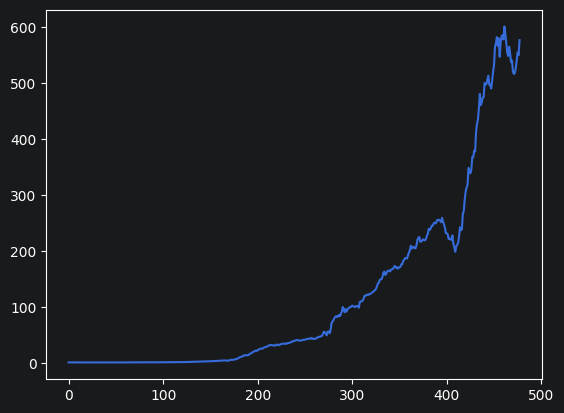

In [285]:
(1 + algo_ret['net_qspread']).cumprod().plot()

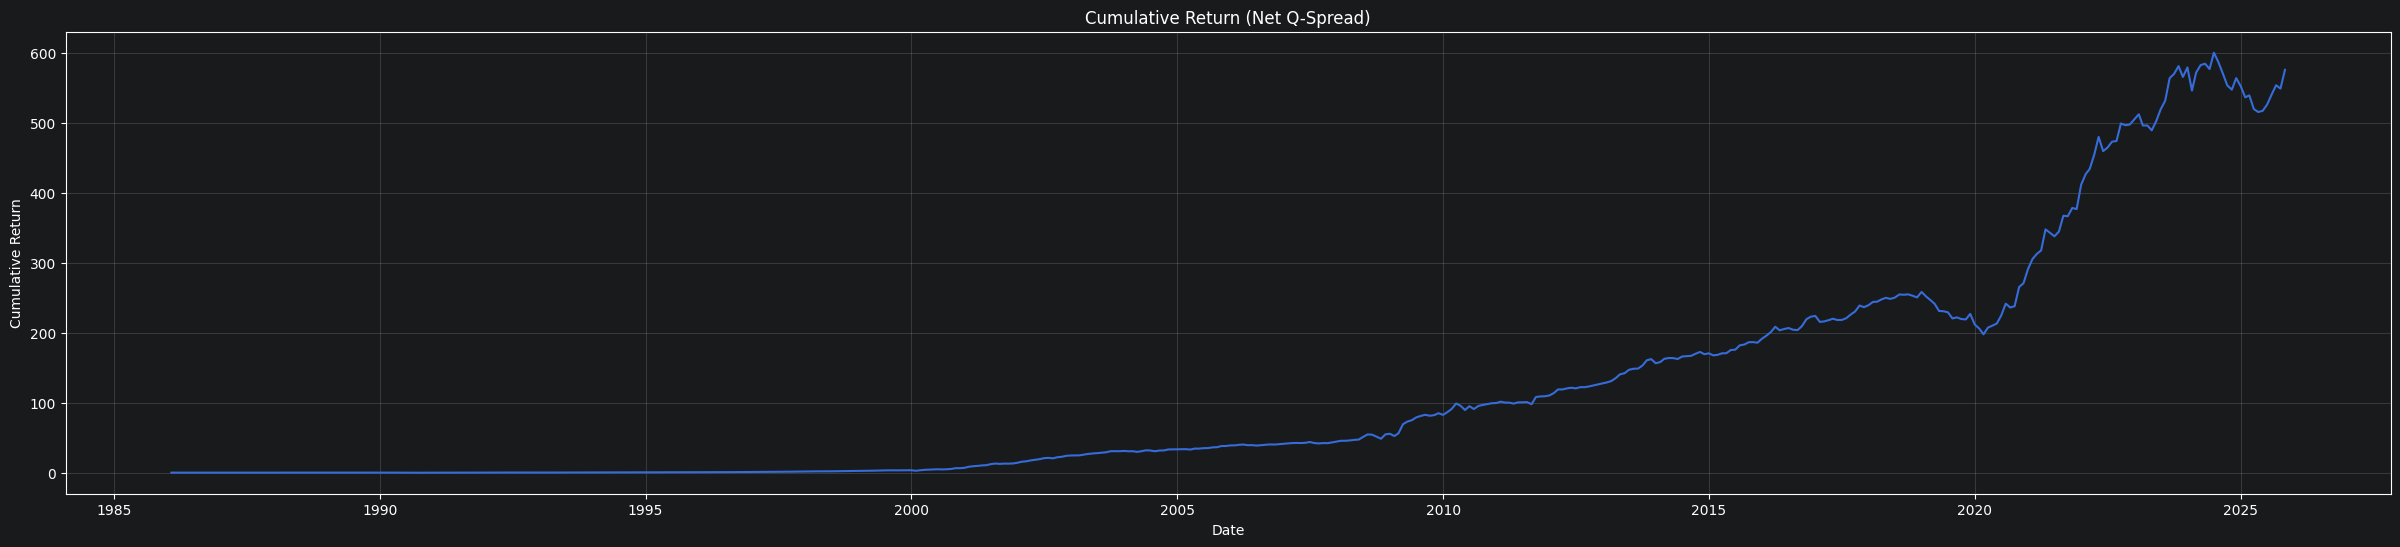

In [286]:
# Ensure datetime
algo_ret['eom'] = pd.to_datetime(algo_ret['eom'])

# Sort by date
xg_boost_ret = algo_ret.sort_values('eom')

# Cumulative return
series = (1 + algo_ret['net_qspread']).cumprod()

# Plot (wider figure)
plt.figure(figsize=(30, 6))
plt.plot(algo_ret['eom'], series)

plt.title('Cumulative Return (Net Q-Spread)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=0.3)

plt.show()

In [287]:
factor_df = pd.read_csv('../data/backtest/xgboost_expanding/feature_importance.csv',  on_bad_lines="skip")
factor_df

,Unnamed: 0,me_company,prc,prc_local,dolvol,ret,enterprise_value,book_equity,assets,sales,...,dstnetis_mev,dbnetis_mev,netis_mev,fincf_mev,eq_dur,mispricing_mgmt,mispricing_perf,age,qmj_prof,qmj_safety
0,1986-01-31,0.010332,0.007373,0.012599,0.007875,0.016186,0.007274,0.007393,0.005991,0.00522,...,0.009631,0.0,0.0,0.0,0.005168,0.005822,0.0,0.006889,0.010848,0.0138
1,1986-02-28,0.010332,0.007373,0.012599,0.007875,0.016186,0.007274,0.007393,0.005991,0.00522,...,0.009631,0.0,0.0,0.0,0.005168,0.005822,0.0,0.006889,0.010848,0.0138
2,1986-03-31,0.010332,0.007373,0.012599,0.007875,0.016186,0.007274,0.007393,0.005991,0.00522,...,0.009631,0.0,0.0,0.0,0.005168,0.005822,0.0,0.006889,0.010848,0.0138
3,1986-04-30,0.010332,0.007373,0.012599,0.007875,0.016186,0.007274,0.007393,0.005991,0.00522,...,0.009631,0.0,0.0,0.0,0.005168,0.005822,0.0,0.006889,0.010848,0.0138
4,1986-05-31,0.010332,0.007373,0.012599,0.007875,0.016186,0.007274,0.007393,0.005991,0.00522,...,0.009631,0.0,0.0,0.0,0.005168,0.005822,0.0,0.006889,0.010848,0.0138
5,1986-06-30,0.010332,0.007373,0.012599,0.007875,0.016186,0.007274,0.007393,0.005991,0.00522,...,0.009631,0.0,0.0,0.0,0.005168,0.005822,0.0,0.006889,0.010848,0.0138
6,1986-07-31,0.010332,0.007373,0.012599,0.007875,0.016186,0.007274,0.007393,0.005991,0.00522,...,0.009631,0.0,0.0,0.0,0.005168,0.005822,0.0,0.006889,0.010848,0.0138
7,1986-08-31,0.010332,0.007373,0.012599,0.007875,0.016186,0.007274,0.007393,0.005991,0.00522,...,0.009631,0.0,0.0,0.0,0.005168,0.005822,0.0,0.006889,0.010848,0.0138
8,1986-09-30,0.010332,0.007373,0.012599,0.007875,0.016186,0.007274,0.007393,0.005991,0.00522,...,0.009631,0.0,0.0,0.0,0.005168,0.005822,0.0,0.006889,0.010848,0.0138
9,1986-10-31,0.010332,0.007373,0.012599,0.007875,0.016186,0.007274,0.007393,0.005991,0.00522,...,0.009631,0.0,0.0,0.0,0.005168,0.005822,0.0,0.006889,0.010848,0.0138


In [288]:
for factor in factor_df:
    print(factor)

Unnamed: 0
me_company
prc
prc_local
dolvol
ret
enterprise_value
book_equity
assets
sales
net_income
bidask
prc_high
prc_low
tvol
chcsho_1m
chcsho_3m
chcsho_6m
chcsho_12m
eqnpo_1m
eqnpo_3m
eqnpo_6m
eqnpo_12m
ret_1_0
ret_2_0
ret_3_0
ret_3_1
ret_6_0
ret_6_1
ret_9_0
ret_9_1
ret_12_0
ret_12_1
ret_12_7
seas_1_1an
at_gr1
ca_gr1
nca_gr1
lt_gr1
cl_gr1
ncl_gr1
be_gr1
debt_gr1
sale_gr1
cogs_gr1
opex_gr1
capx_gr1
inv_gr1
cash_gr1a
inv_gr1a
rec_gr1a
ppeg_gr1a
lti_gr1a
debtst_gr1a
ap_gr1a
txp_gr1a
debtlt_gr1a
txditc_gr1a
coa_gr1a
col_gr1a
cowc_gr1a
ncoa_gr1a
ncol_gr1a
nncoa_gr1a
oa_gr1a
ol_gr1a
fna_gr1a
fnl_gr1a
nfna_gr1a
gp_gr1a
ebitda_gr1a
ebit_gr1a
ope_gr1a
ni_gr1a
nix_gr1a
dp_gr1a
fincf_gr1a
ocf_gr1a
fcf_gr1a
nwc_gr1a
eqnetis_gr1a
dltnetis_gr1a
dbnetis_gr1a
netis_gr1a
eqnpo_gr1a
tax_gr1a
eqbb_gr1a
eqis_gr1a
div_gr1a
eqpo_gr1a
capx_gr1a
be_gr1a
capx_at
spi_at
xido_at
nri_at
gp_sale
ebitda_sale
ebit_sale
pi_sale
ni_sale
nix_sale
ocf_sale
fcf_sale
gp_at
ebitda_at
ebit_at
fi_at
cop_at
ni_at
ope_be
n